#  BEM (Blade Element Momentum) 
# for checking the Power & Thrust Calculator (P=0.5MW)
=======================================================================================
## 500 kW Reference Wind Turbine – RISO-A1-18 Aerofoil
### Physics implemented based on SESM3037 lecture notes:
---
### 🔷 Velocity Triangle
| Parameter | Formula |
|:---|:---|
| Inflow angle | `φ = atan( (1−a)·V₀ / ((1+a′)·Ω·r) )` |
| Angle of attack | `AoA = φ − (twist_angle + pitch_angle)` |

---
### 🔶 Aerodynamic Force Coefficients
| Parameter | Formula |
|:---|:---|
| Normal force | `Cₙ = CL·cos(φ) + CD·sin(φ)` |
| Rotational force | `Cᵣ = CL·sin(φ) − CD·cos(φ)` |

---
### 🔷 Blade Solidity
| Parameter | Formula |
|:---|:---|
| Solidity | `σ = B·c(r) / (2π·r)` |

---
### 🔶 Tip Loss Correction (Prandtl)
| Parameter | Formula |
|:---|:---|
| Loss factor | `F = (2/π)·arccos( exp(−B/2·(R−r) / (r·sin(φ))) )` |

---
### 🔷 Axial Induction Factor
| Condition | Formula |
|:---|:---|
| a ≤ aꜲ | `a = 1 / ( 4F·sin²(φ) / (σ·Cₙ) + 1 )` |
| a > aꜲ *(empirical)* | `linearised CT(a) applied,  aꜲ = 1/3` |

---
### 🔶 Tangential Induction Factor
| Parameter | Formula |
|:---|:---|
| a′ | `a′ = 1 / ( 4F·sin(φ)·cos(φ) / (σ·Cᵣ) − 1 )` |

---
### 🔷 Power & Thrust Integration *(trapezoidal)*
| Quantity | Formula |
|:---|:---|
| Thrust | `T = B · ∫ fₙ dr` |
| Torque | `Q = B · ∫ fᵣ · r dr` |
| Power  | `P = Ω · Q` |

---

# 0.0. Function import

In [2]:
# FUNCTION Import
#%%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os                           # for windows user
from pathlib import Path
# 120 m blade length  ### for task 2

---
# 0.1. Task 1(c) – 1D Actuator Disc Model: Initial Sizing

Using the **Betz limit** to estimate the minimum rotor size needed for a 16 MW turbine.


## print the value we defined...

###  Key Equations
| Parameter | Formula |
|:---|:---|
| Swept area | `A = P_rated / (0.5 · ρ · V₀³ · CP_betz)` |
| Rotor radius | `R = √(A / π)` |
| Angular velocity | `Ω = TSR · V₀ / R` |
| Rotor speed | `RPM = Ω · 60 / (2π)` |

&nbsp;

<div style="border-left: 4px solid steelblue; padding: 8px 12px; border-radius: 4px; background-color: #1e2a3a;">

**Betz limit:**

&nbsp;&nbsp;&nbsp;&nbsp; **CP_max = 16/27 ≈ 0.593**

Derived from 1D Actuator Disc at optimal axial induction a = 1/3

Ref: SESM3037 Lecture – *"1D Actuator Disc Model (5)"*, Slide 39

</div>

In [3]:
# Given parameters (What we set up during first discussion)
P_rated = 16e6        # rated power = 16 [MW]
V0      = 11.0        # nominal wind speed = 11 [m/s]
rho_air = 1.225       # air density = 1.225 [kg/m^3]
N_blade = 3           # number of blades
CP_betz = 16/27       # Betz limit (maximum theoretical CP)

# Estimate rotor swept area
# P = 0.5 * rho * A * V0^3 * CP
A = P_rated / (0.5 * rho_air * V0**3 * CP_betz)
R = np.sqrt(A / np.pi)

print("=== 1D Actuator Disc Model - Initial Sizing ===")
print(f"Rated power:        {P_rated/1e6:.1f} MW")
print(f"Nominal wind speed: {V0:.1f} m/s")
print(f"Betz CP limit:      {CP_betz:.4f}")
print(f"Swept area A:       {A:.1f} m²")
print(f"Blade radius R:     {R:.1f} m")

# Rotation speed from TSR
TSR = 8             # tip speed ratio (but we havent decided yet actually...)
Omega = TSR * V0 / R  # angular velocity [rad/s]
RPM   = Omega * 60 / (2 * np.pi)

print(f"\nTSR:                {TSR}")
print(f"Angular velocity:   {Omega:.3f} rad/s")
print(f"Rotor speed:        {RPM:.2f} RPM")

=== 1D Actuator Disc Model - Initial Sizing ===
Rated power:        16.0 MW
Nominal wind speed: 11.0 m/s
Betz CP limit:      0.5926
Swept area A:       33119.2 m²
Blade radius R:     102.7 m

TSR:                8
Angular velocity:   0.857 rad/s
Rotor speed:        8.18 RPM


---
## File Paths & Output Structure

| Folder/files | details |
|:---|:---|
| `BASE_DIR` | the .py or .ipynb folder |
| `GEOM_CSV` | blade geometry CSV（r, chord, twist） |
| `POLAR_CSV` | polar CSV（α, CL, CD） |
| `OUT_DIR` | output folder（auto build） |

&nbsp;

<div style="border: 2px solid orange; padding: 8px; border-radius: 4px;">
⚠️ <b> Change the file pathway here </b> if your CSVs are in a different location!
</div>

In [4]:
BASE_DIR  = r"C:\Users\user\Downloads\sustainable energy\coding sustainable"
GEOM_CSV  = os.path.join(BASE_DIR, "RISO-A1-A18 Profile for 500kW Reference Turbine Blade.csv")
POLAR_CSV = os.path.join(BASE_DIR, "RISO-A1-A18-Lift-Drag-Characteristics.csv")
OUT_DIR   = os.path.join(BASE_DIR, "bem_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

## 1.  Load blade geometry CSV
### print the CSV 3 Columns....

In [5]:
# ──────────────────────────────────────────────
# 1.  Load blade geometry CSV
# ──────────────────────────────────────────────
def read_geometry(filepath, verbose=True):
    df = pd.read_csv(filepath)
    # Normalise column names to lowercase for consistent matching
    df.columns = [c.strip().lower() for c in df.columns]
    
    # Locate columns by keyword search
    r_col    = next(c for c in df.columns if 'radial' in c or ('r' in c and '(m)' in c))
    beta_col = next(c for c in df.columns if 'twist' in c)
    c_col    = next(c for c in df.columns if 'chord' in c)

    r     = df[r_col].to_numpy(float)       # radial position [m]
    beta  = df[beta_col].to_numpy(float)    # twist angle [deg]
    chord = df[c_col].to_numpy(float)       # chord length [m]

    order = np.argsort(r)
    r, beta, chord = r[order], beta[order], chord[order]
    
    if verbose:  # when verbose=True print the result !!!

        # Print loaded geometry so teammates can verify the data was read correctly
        print("=== Blade Geometry ===")
        print(f"Total nodes: {len(r)}")
        print(f"{'Radius r (m)':<15} {'Twist beta (deg)':<20} {'Chord c (m)'}")
        print("-" * 50)
        for i in range(len(r)):
            print(f"{r[i]:<15.2f} {beta[i]:<20.2f} {chord[i]:.3f}")
        print()

    return r, beta, chord


# Call the function here (OUTSIDE the definition above)
r, beta, chord = read_geometry(GEOM_CSV)
# print the CSV 3 Columns....

#%%



=== Blade Geometry ===
Total nodes: 17
Radius r (m)    Twist beta (deg)     Chord c (m)
--------------------------------------------------
4.50            20.00                1.630
5.50            16.30                1.597
6.50            13.00                1.540
7.50            10.05                1.481
8.50            7.45                 1.420
9.50            5.85                 1.356
10.50           4.85                 1.294
11.50           4.00                 1.229
12.50           3.15                 1.163
13.50           2.60                 1.095
14.50           2.02                 1.026
15.50           1.36                 0.955
16.50           0.77                 0.881
17.50           0.33                 0.806
18.50           0.14                 0.705
19.50           0.05                 0.545
20.30           0.02                 0.265



## 2.  Load polar CSV  (degree  CL  CD)

In [6]:
# ──────────────────────────────────────────────
# 2.  Load polar CSV  (degree  CL  CD)
# ──────────────────────────────────────────────
def read_polar(filepath):
    # file is tab-separated; handle single-column edge-case
    try:
        df = pd.read_csv(filepath, sep=r'\t', engine='python')
        if df.shape[1] == 1:
            raise ValueError
    except Exception:
        df = pd.read_csv(filepath, sep=r'\s+', engine='python')

    df.columns = [c.strip().lower() for c in df.columns]
    alpha = df['degree'].to_numpy(float)
    CL    = df['cl'].to_numpy(float)
    CD    = df['cd'].to_numpy(float)
    order = np.argsort(alpha)
    return alpha[order], CL[order], CD[order]


def interp_polar(alpha_tab, CL_tab, CD_tab, aoa_deg):
    """Piecewise-linear interpolation of CL, CD at given angle of attack."""
    cl = np.interp(aoa_deg, alpha_tab, CL_tab,
                   left=CL_tab[0], right=CL_tab[-1])
    cd = np.interp(aoa_deg, alpha_tab, CD_tab,
                   left=CD_tab[0], right=CD_tab[-1])
    return cl, cd




# 3.  Prandtl tip-loss factor



In [7]:
# ──────────────────────────────────────────────
# 3.  Prandtl tip-loss factor
# ──────────────────────────────────────────────
def prandtl_tip_loss(B, r, R_tip, phi_rad):
    """F = (2/pi)*arccos( exp(-B/2 * (R-r)/(r*sin(phi))) )"""
    sin_phi = abs(np.sin(phi_rad))
    sin_phi = max(sin_phi, 1e-8)
    exponent = (B / 2.0) * (R_tip - r) / (r * sin_phi)
    exponent = max(exponent, 0.0)
    F = (2.0 / np.pi) * np.arccos(np.exp(-exponent))
    return float(np.clip(F, 1e-4, 1.0))

---
## 4. Axial & Tangential Induction Update

### 🔷 Standard Momentum Region (a ≤ aꜲ = 1/3)
| Parameter | Formula |
|:---|:---|
| Intermediate | `K = 4F · sin²(φ) / (σ · Cₙ)` |
| Axial induction | `a = 1 / (K + 1)` |

&nbsp;

### 🔶 High Induction Region (a > aꜲ) — Empirical CT
| Parameter | Formula |
|:---|:---|
| Linearised thrust | `CT_lin = 4F · [ aꜲ² + (1 − 2aꜲ) · a ]` |
| Intermediate | `tmp = 1 − √( 1 + (4/K) · ((1−aꜲ)/(1−2aꜲ))² )` |
| Axial induction | `a = 1 + K · (1−2aꜲ)/2 · tmp` |

&nbsp;

### 🔷 Tangential Induction
| Parameter | Formula |
|:---|:---|
| Tangential | `a′ = 1 / ( 4F·sin(φ)·cos(φ) / (σ·Cᵣ) − 1 )` |

&nbsp;

<div style="border-left: 4px solid steelblue; padding: 8px 12px; border-radius: 4px; background-color: #1e2a3a;">

Standard momentum theory breaks down when a > 1/3.

Ref: SESM3037 Lecture – *"BEM with Empirical CT(a) and F"*, Slide 59

</div>

In [8]:
# ──────────────────────────────────────────────
# 4.  Axial induction from solidity + CN
#     (linearised empirical CT for high induction)
# ──────────────────────────────────────────────
AC = 1.0 / 3.0          # critical axial induction

def update_axial_induction(sigma, CN, phi_rad, F):
    sin2 = np.sin(phi_rad) ** 2
    K = 4.0 * F * max(sin2, 1e-10) / (sigma * max(abs(CN), 1e-10))

    a_std = 1.0 / (K + 1.0)

    if a_std <= AC:
        return float(a_std)

    # high-induction branch (linearised empirical CT)
    ratio = (1.0 - AC) / (1.0 - 2.0 * AC)      # = (2/3)/(1/3) = 2 for ac=1/3
    discriminant = 1.0 + 4.0 / K * ratio ** 2
    discriminant = max(discriminant, 0.0)
    tmp  = 1.0 - np.sqrt(discriminant)
    a_hi = 1.0 + K * (1.0 - 2.0 * AC) / 2.0 * tmp
    return float(np.clip(a_hi, 0.0, 0.95))


def update_tangential_induction(sigma, CR, phi_rad, F):
    """a' from BEM angular-momentum equation."""
    sincos = np.sin(phi_rad) * np.cos(phi_rad)
    denom  = 4.0 * F * sincos / (sigma * max(abs(CR), 1e-10)) - 1.0
    if abs(denom) < 1e-10:
        return 0.0
    ap = 1.0 / denom
    return float(np.clip(ap, -0.5, 2.0))

## 5.  Single-element BEM iteration (from lecture slide coding)

In [9]:
# ────────────────────────────────────────────────────────────────
# 5.  Single-element BEM iteration (from lecture slide coding)
# ────────────────────────────────────────────────────────────────
def solve_element(r_i, chord_i, beta_i, B, V0, Omega, R_tip,
                  alpha_tab, CL_tab, CD_tab,
                  pitch_deg=0.0, max_iter=300, tol=1e-6):
    """
    Iterative BEM solution for one blade element at radius r_i.
    Returns: a, a', phi[rad], AoA[deg], CL, CD, CN, CR, F
    """
    sigma = B * chord_i / (2.0 * np.pi * r_i)
    a  = 0.3          # initial guesses
    ap = 0.0

    for _ in range(max_iter): # run iterarion until solution converge
        Vax  = V0 * (1.0 - a)
        Vtan = Omega * r_i * (1.0 + ap)
        Vtan = max(Vtan, 1e-10)

        phi = np.arctan2(Vax, Vtan)
        phi = float(np.clip(phi, 1e-6, np.pi / 2 - 1e-6))

        F   = prandtl_tip_loss(B, r_i, R_tip, phi)
        aoa = np.degrees(phi) - (beta_i + pitch_deg)

        CL, CD = interp_polar(alpha_tab, CL_tab, CD_tab, aoa)
        CN = CL * np.cos(phi) + CD * np.sin(phi)
        CR = CL * np.sin(phi) - CD * np.cos(phi)

        a_new  = update_axial_induction(sigma, CN, phi, F)
        ap_new = update_tangential_induction(sigma, CR, phi, F)

        # under-relaxation for stability
        relax  = 0.3
        a_new  = (1 - relax) * a  + relax * a_new
        ap_new = (1 - relax) * ap + relax * ap_new

        if abs(a_new - a) < tol and abs(ap_new - ap) < tol:
            a, ap = a_new, ap_new
            break
        a, ap = a_new, ap_new

    return a, ap, phi, aoa, CL, CD, CN, CR, F




## 6.  Full rotor BEM at one wind speed

In [10]:
# ──────────────────────────────────────────────
# 6.  Full rotor BEM at one wind speed
# ──────────────────────────────────────────────

"""
    Run BEM over all blade elements and integrate thrust & power.

    Uses the actual node positions from the CSV as the element radii
    (no re-meshing – keeps it transparent).

    Returns:
      P_W   – shaft power [W]
      T_N   – rotor thrust [N]
      CP    – power coefficient [-]
      CT    – thrust coefficient [-]
      dist  – DataFrame with spanwise results
"""
def rotor_bem(r_nodes, beta_nodes, chord_nodes,
              alpha_tab, CL_tab, CD_tab,
              V0, TSR, pitch_deg=0.0, B=3, rho=1.225):
    
    R_tip = r_nodes[-1]
    Omega = TSR * V0 / R_tip

    N = len(r_nodes)
    results = []

    for i in range(N):
        a, ap, phi, aoa, cl, cd, CN, CR, F = solve_element(
            r_i=r_nodes[i], chord_i=chord_nodes[i], beta_i=beta_nodes[i],
            B=B, V0=V0, Omega=Omega, R_tip=R_tip,
            alpha_tab=alpha_tab, CL_tab=CL_tab, CD_tab=CD_tab,
            pitch_deg=pitch_deg
        )

        Vax  = V0  * (1.0 - a)
        Vtan = Omega * r_nodes[i] * (1.0 + ap)
        Vrel2 = Vax**2 + Vtan**2

        # force per unit span [N/m]
        fN = 0.5 * rho * Vrel2 * chord_nodes[i] * CN
        fR = 0.5 * rho * Vrel2 * chord_nodes[i] * CR

        results.append(dict(
            r=r_nodes[i], chord=chord_nodes[i], beta=beta_nodes[i],
            a=a, ap=ap, phi_deg=np.degrees(phi), aoa_deg=aoa,
            F=F, CL=cl, CD=cd,
            fN=fN, fR=fR
        ))

    df = pd.DataFrame(results)

    # ── Segment integration (trapezoidal between adjacent nodes) ──────────
    # Thrust segment i: T_i = 0.5*(fN_i+1 + fN_i)*(r_i+1 - r_i) * B
    # Torque segment i: Q_i ≈ 0.5*(fR_i+1*r_i+1 + fR_i*r_i)*(r_i+1 - r_i) * B
    T = 0.0
    Q = 0.0
    for i in range(N - 1):
        dr  = df['r'].iloc[i+1] - df['r'].iloc[i]
        T  += B * 0.5 * (df['fN'].iloc[i+1] + df['fN'].iloc[i]) * dr
        Q  += B * 0.5 * (df['fR'].iloc[i+1] * df['r'].iloc[i+1]
                        + df['fR'].iloc[i]   * df['r'].iloc[i]) * dr

    P   = Omega * Q
    A   = np.pi * R_tip**2
    CP  = P  / (0.5 * rho * A * V0**3)
    CT  = T  / (0.5 * rho * A * V0**2)
    rpm = Omega * 60.0 / (2.0 * np.pi)

    return P, T, Q, CP, CT, rpm, df




## 7.  Wind-speed sweep

In [11]:
# ──────────────────────────────────────────────
# 7.  Wind-speed sweep
# ──────────────────────────────────────────────
def wind_sweep(geom_csv, polar_csv,
               V_range=(4, 20, 1),
               TSR=7.5, pitch_deg=0.0, B=3, rho=1.225):
    """
    Sweep wind speeds from V_min to V_max (step V_step).
    Returns a summary DataFrame.
    """
    r_nodes, beta_nodes, chord_nodes = read_geometry(geom_csv, verbose=False)
    alpha_tab, CL_tab, CD_tab       = read_polar(polar_csv)

    V_min, V_max, V_step = V_range
    wind_speeds = np.arange(V_min, V_max + V_step * 0.5, V_step)

    rows = []
    for V0 in wind_speeds:
        P, T, Q, CP, CT, rpm, _ = rotor_bem(
            r_nodes, beta_nodes, chord_nodes,
            alpha_tab, CL_tab, CD_tab,
            V0=V0, TSR=TSR, pitch_deg=pitch_deg, B=B, rho=rho
        )
        rows.append(dict(
            V0_mps=V0, rpm=rpm,
            P_kW=P/1000, Q_Nm=Q, T_N=T,
            CP=CP, CT=CT
        ))
        print(f"  V0={V0:5.1f} m/s  P={P/1000:7.1f} kW  T={T/1000:6.1f} kN  "
              f"CP={CP:.3f}  CT={CT:.3f}")

    summary = pd.DataFrame(rows)
    return summary

# ──────────────────────────────────────────────
# 6b. Pitch regulation
# ──────────────────────────────────────────────
def find_pitch_for_target_power(
    r_nodes, beta_nodes, chord_nodes,
    alpha_tab, CL_tab, CD_tab,
    V0, TSR,
    target_power_kW=500.0,
    max_pitch_deg=30.0,
    pitch_tolerance_kW=0.5,
    max_iter=40
):
    """
    Bisection to find pitch angle that holds power near target_power_kW.
    Returns dict with P_kW, T_N, Q_Nm, CP, CT, rpm, pitch_deg, converged.
    """
    # Check if pitch control is even needed
    P, T, Q, CP, CT, rpm, dist = rotor_bem(
        r_nodes, beta_nodes, chord_nodes,
        alpha_tab, CL_tab, CD_tab,
        V0=V0, TSR=TSR, pitch_deg=0.0
    )
    if P / 1000 <= target_power_kW + pitch_tolerance_kW:
        return dict(P_kW=P/1000, T_N=T, Q_Nm=Q,
                    CP=CP, CT=CT, rpm=rpm,
                    pitch_deg=0.0, converged=True)

    lo, hi = 0.0, max_pitch_deg
    best = None
    best_err = float('inf')

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        P, T, Q, CP, CT, rpm, dist = rotor_bem(
            r_nodes, beta_nodes, chord_nodes,
            alpha_tab, CL_tab, CD_tab,
            V0=V0, TSR=TSR, pitch_deg=mid
        )
        P_kW = P / 1000
        err = abs(P_kW - target_power_kW)

        if err < best_err:
            best_err = err
            best = dict(P_kW=P_kW, T_N=T, Q_Nm=Q,
                        CP=CP, CT=CT, rpm=rpm,
                        pitch_deg=mid, converged=False)

        if err <= pitch_tolerance_kW:
            best['converged'] = True
            return best

        if P_kW > target_power_kW:
            lo = mid
        else:
            hi = mid

    return best



## 8.  Run & plot (Task 1(e) - Verify with 0.5MW turbine)
### 4 plots


Running BEM sweep …
  V0=  4.0 m/s  P=   23.0 kW  T=  10.6 kN  CP=0.454  CT=0.839
  V0=  5.0 m/s  P=   45.0 kW  T=  16.6 kN  CP=0.454  CT=0.839
  V0=  6.0 m/s  P=   77.7 kW  T=  23.9 kN  CP=0.454  CT=0.839
  V0=  7.0 m/s  P=  123.4 kW  T=  32.6 kN  CP=0.454  CT=0.839
  V0=  8.0 m/s  P=  184.3 kW  T=  42.6 kN  CP=0.454  CT=0.839
  V0=  9.0 m/s  P=  262.3 kW  T=  53.9 kN  CP=0.454  CT=0.839
  V0= 10.0 m/s  P=  359.9 kW  T=  66.5 kN  CP=0.454  CT=0.839
  V0= 11.0 m/s  P=  479.0 kW  T=  80.5 kN  CP=0.454  CT=0.839
  V0= 12.0 m/s  P=  621.8 kW  T=  95.8 kN  CP=0.454  CT=0.839
  V0= 13.0 m/s  P=  790.6 kW  T= 112.4 kN  CP=0.454  CT=0.839
  V0= 14.0 m/s  P=  987.5 kW  T= 130.3 kN  CP=0.454  CT=0.839
  V0= 15.0 m/s  P= 1214.5 kW  T= 149.6 kN  CP=0.454  CT=0.839
  V0= 16.0 m/s  P= 1474.0 kW  T= 170.2 kN  CP=0.454  CT=0.839
  V0= 17.0 m/s  P= 1768.0 kW  T= 192.2 kN  CP=0.454  CT=0.839
  V0= 18.0 m/s  P= 2098.7 kW  T= 215.5 kN  CP=0.454  CT=0.839
  V0= 19.0 m/s  P= 2468.3 kW  T= 240.1 kN  CP=0.45

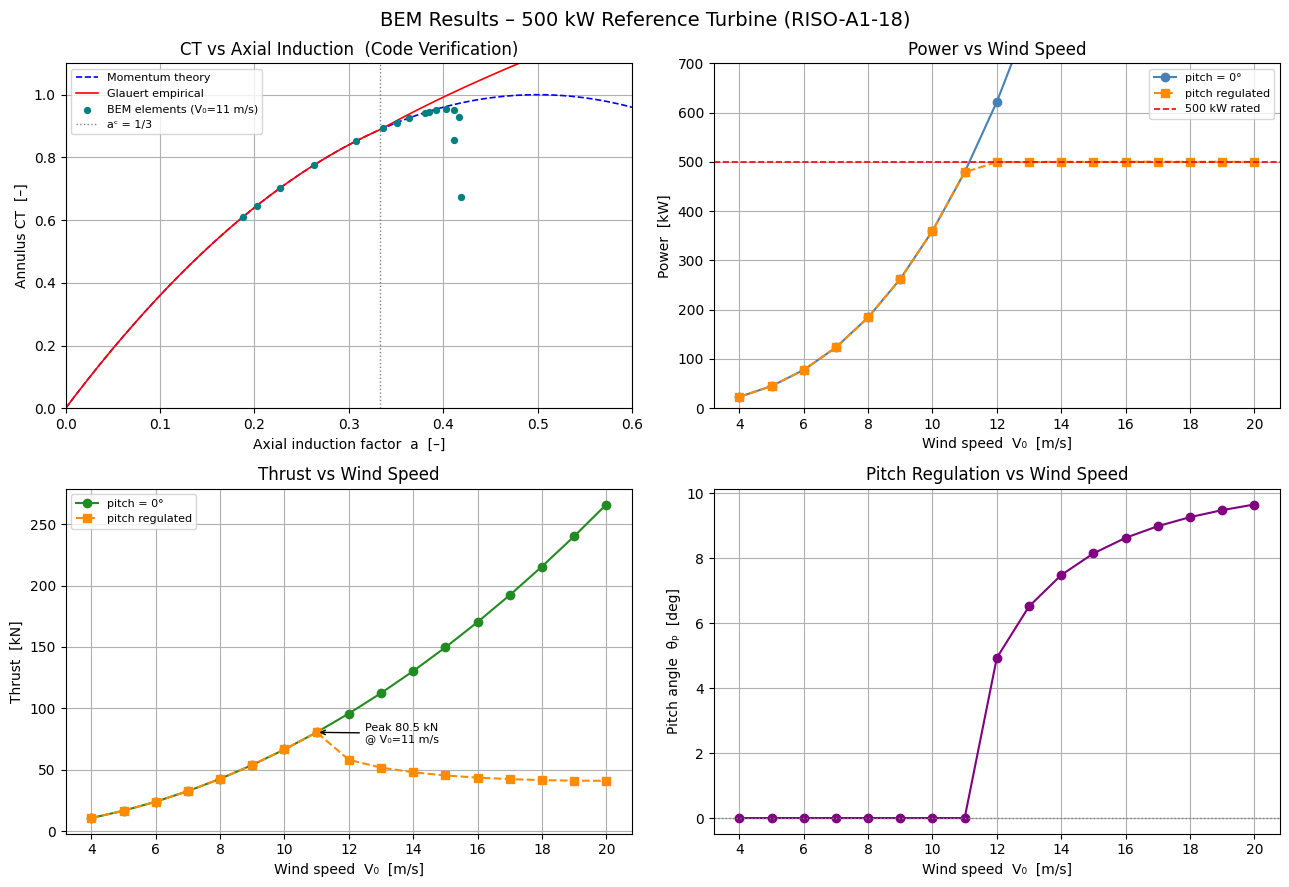

Main plot saved → C:\Users\user\Downloads\sustainable energy\coding sustainable\bem_outputs\bem_result_plot.png


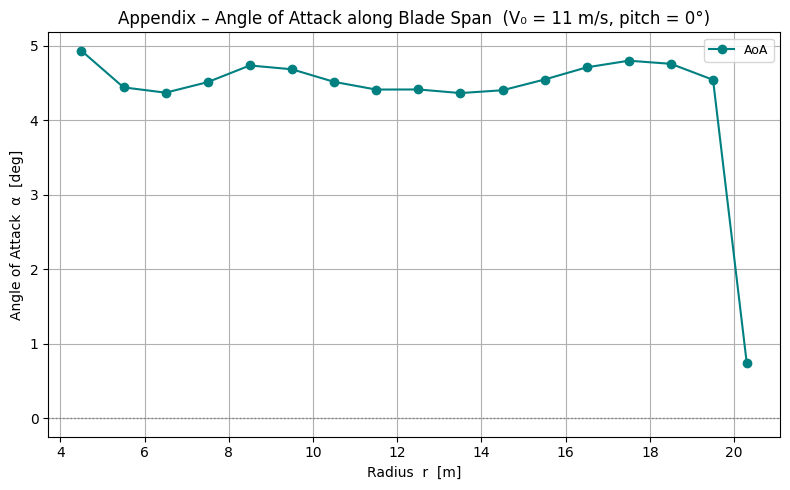

due to The sharp decrease in angle of attack near the blade tip (r ≈ 20 m) is attributed to the Prandtl tip loss correction, where the loss factor F → 0 reduces the effective induction and alters the local inflow angle, resulting in a lower angle of attack at the outermost element.
Appendix plot saved → C:\Users\user\Downloads\sustainable energy\coding sustainable\bem_outputs\bem_appendix_AoA.png


In [12]:
# ──────────────────────────────────────────────
# 8.  Run & plot (Task 1(e) - Verify with 0.5MW turbine)
# ──────────────────────────────────────────────

# ── Load data for plots ──────────────────────
r_nodes, beta_nodes, chord_nodes = read_geometry(GEOM_CSV, verbose=False)
alpha_tab, CL_tab, CD_tab = read_polar(POLAR_CSV)

print("Running BEM sweep …")
summary = wind_sweep(
    GEOM_CSV, POLAR_CSV,
    V_range=(4, 20, 1),
    TSR=8,
    pitch_deg=0.0
)

# Betz sanity check
if (summary['CP'] > 0.593).any():
    print("WARNING: some CP values exceed Betz limit – check inputs.")

# Save summary CSV
csv_out = os.path.join(OUT_DIR, "bem_power_thrust.csv")
summary.to_csv(csv_out, index=False, float_format="%.4f")
print(f"\nSummary saved → {csv_out}")



# ── Verification summary (Task 1e) ──────────────
print("\n=== Verification Summary (Task 1e) ===")
print(f"Expected rated power:  ~500 kW")
print(f"Achieved at V0=11 m/s: {summary[summary['V0_mps']==11.0]['P_kW'].values[0]:.1f} kW")
print(f"Mean CP = {summary['CP'].mean():.3f} (below Betz limit 0.593) ✓")
print(f"Mean CT = {summary['CT'].mean():.3f} (physically reasonable)  ✓")

# ── Power regulation + build summary ────────────────────────────
P_rated_kW = 500.0

rows_unreg = []
rows_reg   = []

for _, row in summary.iterrows():
    V0 = row['V0_mps']

    if row['P_kW'] <= P_rated_kW:
        # Below rated: pitch=0, regulated = unregulated
        rows_unreg.append(row.to_dict())
        rows_reg.append({**row.to_dict(), 'pitch_deg': 0.0})
    else:
        # Above rated: find pitch
        rows_unreg.append({**row.to_dict(), 'pitch_deg': 0.0})
        result = find_pitch_for_target_power(
            r_nodes, beta_nodes, chord_nodes,
            alpha_tab, CL_tab, CD_tab,
            V0=V0, TSR=TSR
        )
        rows_reg.append({
            'V0_mps': V0,
            'rpm':    result['rpm'],
            'P_kW':   result['P_kW'],
            'Q_Nm':   result['Q_Nm'],
            'T_N':    result['T_N'],
            'CP':     result['CP'],
            'CT':     result['CT'],
            'pitch_deg': result['pitch_deg'],
        })
        if not result['converged']:
            print(f"  WARNING: V0={V0} m/s pitch not fully converged "
                  f"(best={result['pitch_deg']:.2f}°, P={result['P_kW']:.1f} kW)")

summary_unreg = pd.DataFrame(rows_unreg)
summary_regulated = pd.DataFrame(rows_reg)

# Save regulated summary CSV
reg_csv_out = os.path.join(OUT_DIR, "bem_regulated.csv")
summary_regulated.to_csv(reg_csv_out, index=False, float_format="%.4f")
print(f"Regulated summary saved → {reg_csv_out}")

print("\nPitch schedule:")
print(summary_regulated[['V0_mps', 'P_kW', 'pitch_deg']].to_string(index=False))

# print(f"V_rated = {V_rated} m/s")
# print(summary_regulated[['V0_mps', 'P_kW', 'pitch']])
# check output

#=================================================================

# ── 4-panel Main Plot ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
V = summary_unreg['V0_mps'].values

# ── 1) CT vs axial induction factor a (Code Verification) ───────────────────
_, _, _, _, _, _, dist_nom = rotor_bem(
    r_nodes, beta_nodes, chord_nodes,
    alpha_tab, CL_tab, CD_tab,
    V0=11.0, TSR=7.5
)

#===========================
a_vals  = dist_nom['a'].values
a_vals = dist_nom['a'].values
F_vals = dist_nom['F'].values

# CT from momentum theory per element: CT = 4*F*a*(1-a)
CT_vals = 4 * F_vals * a_vals * (1 - a_vals)
#==============================

# Theoretical reference curves
a_th = np.linspace(0, 0.6, 300)
ac   = 1/3
CT_momentum  = 4 * a_th * (1 - a_th)
CT_empirical = np.where(
    a_th <= ac,
    4 * a_th * (1 - a_th),
    4 * a_th * (1 - 0.25*(5 - 3*a_th)*a_th)
)

axes[0, 0].plot(a_th, CT_momentum,  'b--', lw=1.2, label='Momentum theory')
axes[0, 0].plot(a_th, CT_empirical, 'r-',  lw=1.2, label='Glauert empirical')
axes[0, 0].scatter(a_vals, CT_vals, s=18, color='teal', zorder=5,
                   label='BEM elements (V₀=11 m/s)')
axes[0, 0].axvline(ac, color='gray', ls=':', lw=1, label='aᶜ = 1/3')
axes[0, 0].set_xlabel('Axial induction factor  a  [–]')
axes[0, 0].set_ylabel('Annulus CT  [–]')
axes[0, 0].set_title('CT vs Axial Induction  (Code Verification)')
axes[0, 0].set_xlim(0, 0.6);  axes[0, 0].set_ylim(0, 1.1)
axes[0, 0].legend(fontsize=8);  axes[0, 0].grid(True)

# ── 2) Power vs Wind Speed ───────────────────────────────────────────────────
axes[0, 1].plot(V, summary_unreg['P_kW'],     'o-',  color='steelblue',
                label='pitch = 0°')
axes[0, 1].plot(V, summary_regulated['P_kW'], 's--', color='darkorange',
                label='pitch regulated')
axes[0, 1].axhline(500, ls='--', color='red', lw=1.2, label='500 kW rated')
axes[0, 1].set_xlabel('Wind speed  V₀  [m/s]')
axes[0, 1].set_ylabel('Power  [kW]')
axes[0, 1].set_title('Power vs Wind Speed')
axes[0, 1].set_ylim(0, 700)
axes[0, 1].legend(fontsize=8);  axes[0, 1].grid(True)

# ── 3) Thrust vs Wind Speed ──────────────────────────────────────────────────
axes[1, 0].plot(V, summary_unreg['T_N']/1e3,     'o-',  color='forestgreen',
                label='pitch = 0°')
axes[1, 0].plot(V, summary_regulated['T_N']/1e3, 's--', color='darkorange',
                label='pitch regulated')

# Mark peak thrust
T_peak = summary_regulated['T_N'].max() / 1e3
V_peak = summary_regulated.loc[summary_regulated['T_N'].idxmax(), 'V0_mps']
axes[1, 0].annotate(f'Peak {T_peak:.1f} kN\n@ V₀={V_peak:.0f} m/s',
                    xy=(V_peak, T_peak),
                    xytext=(V_peak + 1.5, T_peak - 8),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    fontsize=8)

axes[1, 0].set_xlabel('Wind speed  V₀  [m/s]')
axes[1, 0].set_ylabel('Thrust  [kN]')
axes[1, 0].set_title('Thrust vs Wind Speed')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# ── 4) Pitch angle vs Wind Speed ─────────────────────────────────────────────
axes[1, 1].plot(V, summary_regulated['pitch_deg'], 'o-', color='purple')
axes[1, 1].axhline(0, color='gray', ls=':', lw=1)
axes[1, 1].set_xlabel('Wind speed  V₀  [m/s]')
axes[1, 1].set_ylabel('Pitch angle  θₚ  [deg]')
axes[1, 1].set_title('Pitch Regulation vs Wind Speed')
axes[1, 1].grid(True)

fig.suptitle("BEM Results – 500 kW Reference Turbine (RISO-A1-18)", fontsize=14)
fig.tight_layout()
plot_out = os.path.join(OUT_DIR, "bem_result_plot.png")
fig.savefig(plot_out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Main plot saved → {plot_out}")


# ── Appendix Plot: AoA along blade span ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(dist_nom['r'], dist_nom['aoa_deg'], 'o-', color='teal', label='AoA')
ax2.axhline(0, color='gray', ls=':', lw=1)
ax2.set_xlabel('Radius  r  [m]')
ax2.set_ylabel('Angle of Attack  α  [deg]')
ax2.set_title('Appendix – Angle of Attack along Blade Span  (V₀ = 11 m/s, pitch = 0°)')
ax2.legend(fontsize=9);  ax2.grid(True)
fig2.tight_layout()
plot_app = os.path.join(OUT_DIR, "bem_appendix_AoA.png")
fig2.savefig(plot_app, dpi=180, bbox_inches='tight')
plt.show()
print('due to The sharp decrease in angle of attack near the blade tip (r ≈ 20 m) is attributed to the Prandtl tip loss correction, where the loss factor F → 0 reduces the effective induction and alters the local inflow angle, resulting in a lower angle of attack at the outermost element.')
print(f"Appendix plot saved → {plot_app}")

#%%

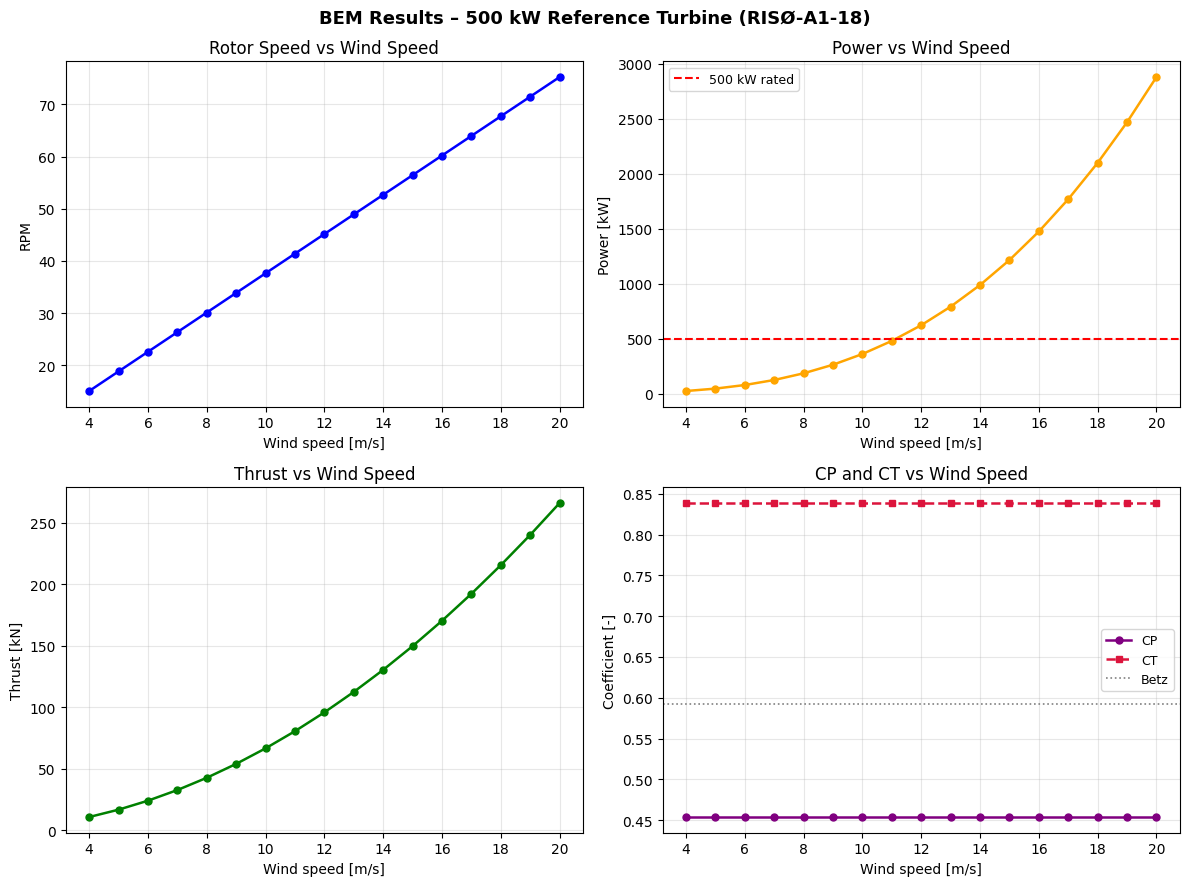

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('BEM Results – 500 kW Reference Turbine (RISØ-A1-18)',
             fontsize=13, fontweight='bold')

V0      = summary['V0_mps'].values
P       = summary['P_kW'].values
T       = summary['T_N'].values / 1000   # N → kN
CP      = summary['CP'].values
CT      = summary['CT'].values
RPM_arr = summary['rpm'].values

# ── 1) Rotor Speed ────────────────────────────────────
ax = axes[0, 0]
ax.plot(V0, RPM_arr, 'b-o', ms=5, lw=1.8)
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('RPM')
ax.set_title('Rotor Speed vs Wind Speed')
ax.grid(alpha=0.3)

# ── 2) Power ──────────────────────────────────────────
ax = axes[0, 1]
ax.plot(V0, P, 'o-', color='orange', ms=5, lw=1.8)
ax.axhline(500, color='red', ls='--', lw=1.5, label='500 kW rated')
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Power [kW]')
ax.set_title('Power vs Wind Speed')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 3) Thrust ─────────────────────────────────────────
ax = axes[1, 0]
ax.plot(V0, T, 'g-o', ms=5, lw=1.8)
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Thrust [kN]')
ax.set_title('Thrust vs Wind Speed')
ax.grid(alpha=0.3)

# ── 4) CP and CT ──────────────────────────────────────
ax = axes[1, 1]
ax.plot(V0, CP, 'o-',  color='purple', ms=5, lw=1.8, label='CP')
ax.plot(V0, CT, 's--', color='crimson', ms=5, lw=1.8, label='CT')
ax.axhline(16/27, color='gray', ls=':', lw=1.2, label='Betz')
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Coefficient [-]')
ax.set_title('CP and CT vs Wind Speed')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task1_four_panel.png', dpi=150)
plt.show()

In [14]:
print(summary.columns.tolist())
print(summary.head(2))

['V0_mps', 'rpm', 'P_kW', 'Q_Nm', 'T_N', 'CP', 'CT']
   V0_mps        rpm       P_kW          Q_Nm           T_N       CP        CT
0     4.0  15.053078  23.031435  14610.566755  10639.985182  0.45383  0.838635
1     5.0  18.816348  44.983272  22829.010555  16624.976847  0.45383  0.838635


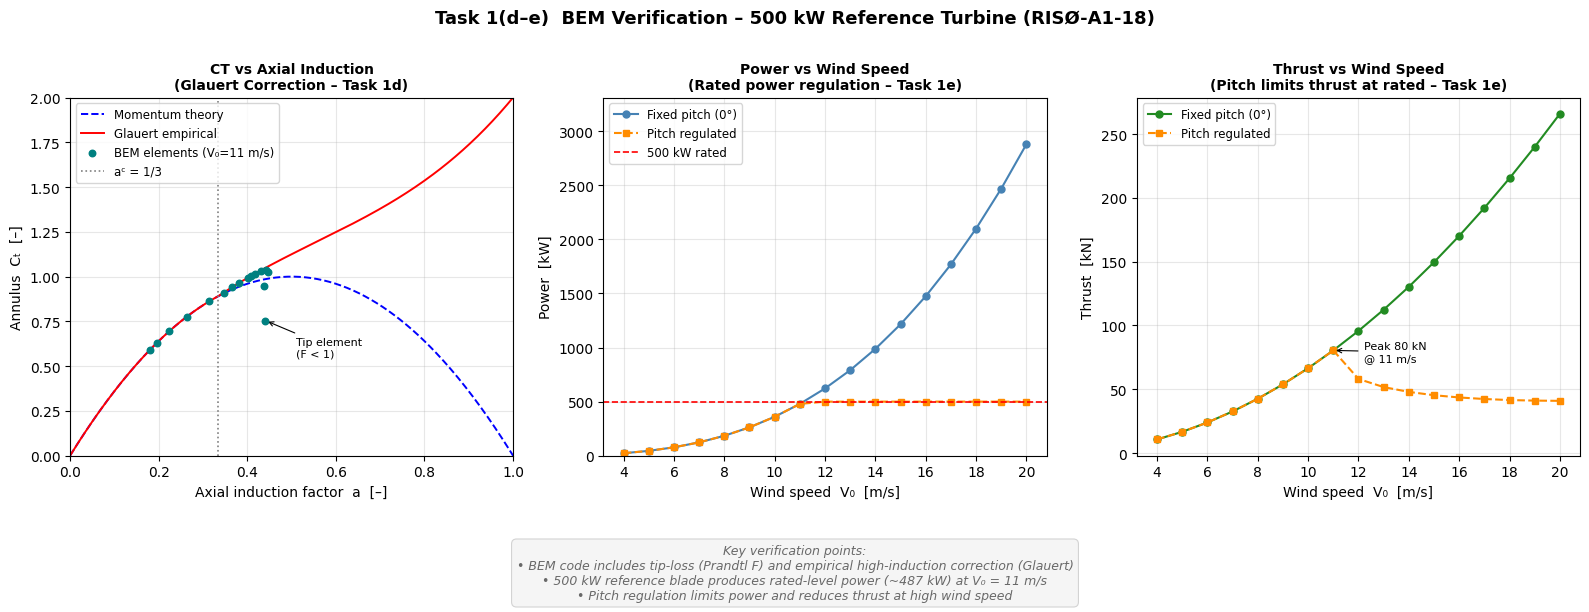

Saved → C:\Users\user\Downloads\sustainable energy\coding sustainable\bem_outputs\task1_slide_3panel.png


In [20]:
# ══════════════════════════════════════════════════════════════════
# Task 1(d-e)  Slide Figure — 1×3 layout
# [CT vs a]  [Power vs V₀]  [Thrust vs V₀]
# ══════════════════════════════════════════════════════════════════



fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Task 1(d–e)  BEM Verification – 500 kW Reference Turbine (RISØ-A1-18)',
    fontsize=13, fontweight='bold', y=1.01
)

# colour palette
C_UNREG = 'steelblue'
C_REG   = 'darkorange'
C_RATED = 'red'

# ── Shared data (re-use what's already computed above) ────────────
V   = summary_unreg['V0_mps'].values
Pu  = summary_unreg['P_kW'].values
Tu  = summary_unreg['T_N'].values / 1e3
Pr  = summary_regulated['P_kW'].values
Tr  = summary_regulated['T_N'].values / 1e3

ac = 1 / 3

# ─── Plot 1: CT vs Axial Induction (Task 1d key verification) ────
ax = axes[0]
a_th       = np.linspace(0, 1, 300)
CT_mom     = 4 * a_th * (1 - a_th)
CT_glauert = np.where(
    a_th <= ac,
    4 * a_th * (1 - a_th),
    4 * a_th * (1 - 0.25 * (5 - 3 * a_th) * a_th)
)
ax.plot(a_th, CT_mom,     'b--', lw=1.4, label='Momentum theory')
ax.plot(a_th, CT_glauert, 'r-',  lw=1.4, label='Glauert empirical')
ax.scatter(a_plot, CT_plot, s=22, color='teal', zorder=5,
           label='BEM elements (V₀=11 m/s)')
ax.axvline(ac, color='gray', ls=':', lw=1.2, label='aᶜ = 1/3')
ax.set_xlim(0, 1);  ax.set_ylim(0, 2.0)
ax.set_xlabel('Axial induction factor  a  [–]', fontsize=10)
ax.set_ylabel('Annulus  Cₜ  [–]', fontsize=10)
ax.set_title('CT vs Axial Induction\n(Glauert Correction – Task 1d)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5);  ax.grid(alpha=0.3)

# annotate tip element
ax.annotate('Tip element\n(F < 1)',
            xy=(a_tip, CT_tip),
            xytext=(a_tip + 0.07, CT_tip - 0.2),
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            fontsize=8)

# ─── Plot 2: Power vs Wind Speed ──────────────────────────────────
ax = axes[1]
ax.plot(V, Pu, 'o-',  color=C_UNREG, ms=5, lw=1.5, label='Fixed pitch (0°)')
ax.plot(V, Pr, 's--', color=C_REG,   ms=5, lw=1.5, label='Pitch regulated')
ax.axhline(500, ls='--', color=C_RATED, lw=1.2, label='500 kW rated')
ax.set_xlabel('Wind speed  V₀  [m/s]', fontsize=10)
ax.set_ylabel('Power  [kW]', fontsize=10)
ax.set_title('Power vs Wind Speed\n(Rated power regulation – Task 1e)',
             fontsize=10, fontweight='bold')
ax.set_ylim(0, max(Pu) * 1.15)
ax.legend(fontsize=8.5);  ax.grid(alpha=0.3)

# ─── Plot 3: Thrust vs Wind Speed ─────────────────────────────────
ax = axes[2]
ax.plot(V, Tu, 'o-',  color='forestgreen', ms=5, lw=1.5, label='Fixed pitch (0°)')
ax.plot(V, Tr, 's--', color=C_REG,         ms=5, lw=1.5, label='Pitch regulated')

# annotate peak regulated thrust
idx_pk = np.argmax(Tr)
ax.annotate(f'Peak {Tr[idx_pk]:.0f} kN\n@ {V[idx_pk]:.0f} m/s',
            xy=(V[idx_pk], Tr[idx_pk]),
            xytext=(V[idx_pk] + 1.2, Tr[idx_pk] - 8),
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            fontsize=8)
ax.set_xlabel('Wind speed  V₀  [m/s]', fontsize=10)
ax.set_ylabel('Thrust  [kN]', fontsize=10)
ax.set_title('Thrust vs Wind Speed\n(Pitch limits thrust at rated – Task 1e)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5);  ax.grid(alpha=0.3)

# ── Key verification text box ─────────────────────────────────────
note = (
    "Key verification points:\n"
    "• BEM code includes tip-loss (Prandtl F) and empirical high-induction correction (Glauert)\n"
    "• 500 kW reference blade produces rated-level power (~487 kW) at V₀ = 11 m/s\n"
    "• Pitch regulation limits power and reduces thrust at high wind speed"
)
fig.text(0.5, -0.06, note, ha='center', va='top', fontsize=9,
         style='italic', color='dimgray',
         bbox=dict(boxstyle='round,pad=0.4', fc='#f5f5f5', ec='lightgray', lw=0.8))

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
slide_out = os.path.join(OUT_DIR, 'task1_slide_3panel.png')
fig.savefig(slide_out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved → {slide_out}")

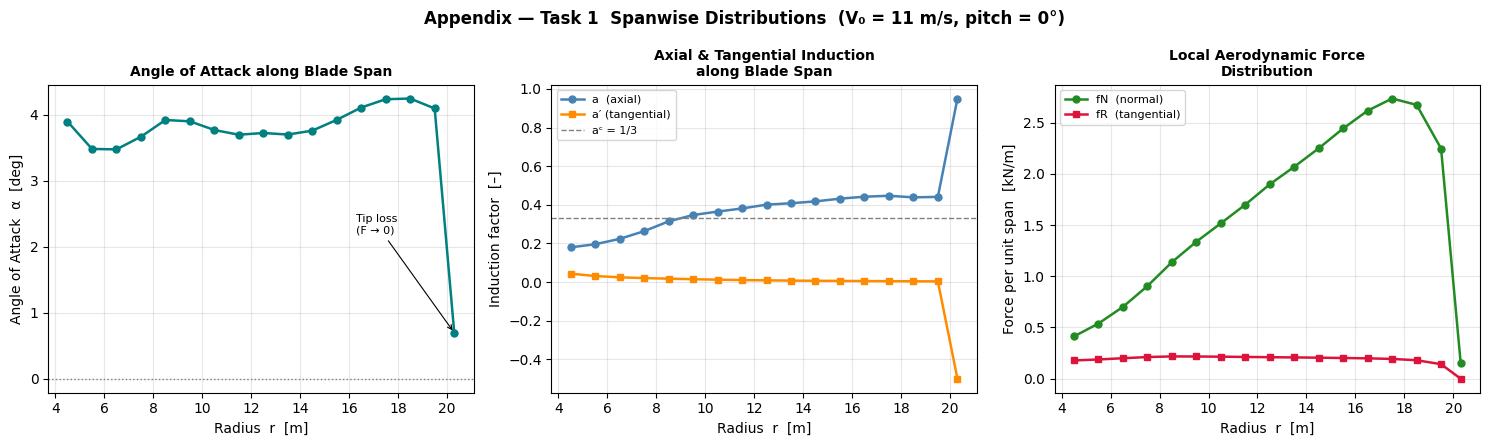

Appendix saved → C:\Users\user\Downloads\sustainable energy\coding sustainable\bem_outputs\task1_appendix_spanwise.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
# APPENDIX — Task 1  Spanwise Distributions (V₀ = 11 m/s)
# ══════════════════════════════════════════════════════════════════

r    = dist_slide['r'].values
aoa  = dist_slide['aoa_deg'].values
a    = dist_slide['a'].values
ap   = dist_slide['ap'].values
fN   = dist_slide['fN'].values / 1e3    # N/m → kN/m
fR   = dist_slide['fR'].values / 1e3
F    = dist_slide['F'].values
CL   = dist_slide['CL'].values
CD   = dist_slide['CD'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    'Appendix — Task 1  Spanwise Distributions  (V₀ = 11 m/s, pitch = 0°)',
    fontsize=12, fontweight='bold'
)

# ── A1) Angle of Attack ───────────────────────────────────────────
ax = axes[0]
ax.plot(r, aoa, 'o-', color='teal', ms=5, lw=1.8)
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Radius  r  [m]', fontsize=10)
ax.set_ylabel('Angle of Attack  α  [deg]', fontsize=10)
ax.set_title('Angle of Attack along Blade Span', fontsize=10,
             fontweight='bold')
ax.annotate('Tip loss\n(F → 0)',
            xy=(r[-1], aoa[-1]),
            xytext=(r[-1] - 4, aoa[-1] + 1.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            fontsize=8)
ax.grid(alpha=0.3)

# ── A2) Induction Factors ─────────────────────────────────────────
ax = axes[1]
ax.plot(r, a,  'o-', color='steelblue',  ms=5, lw=1.8, label="a  (axial)")
ax.plot(r, ap, 's-', color='darkorange', ms=5, lw=1.8, label="a′ (tangential)")
ax.axhline(1/3, color='gray', ls='--', lw=1, label='aᶜ = 1/3')
ax.set_xlabel('Radius  r  [m]', fontsize=10)
ax.set_ylabel('Induction factor  [–]', fontsize=10)
ax.set_title('Axial & Tangential Induction\nalong Blade Span', fontsize=10,
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── A3) Local Aerodynamic Forces ──────────────────────────────────
ax = axes[2]
ax.plot(r, fN, 'o-', color='forestgreen', ms=5, lw=1.8, label='fN  (normal)')
ax.plot(r, fR, 's-', color='crimson',     ms=5, lw=1.8, label='fR  (tangential)')
ax.set_xlabel('Radius  r  [m]', fontsize=10)
ax.set_ylabel('Force per unit span  [kN/m]', fontsize=10)
ax.set_title('Local Aerodynamic Force\nDistribution', fontsize=10,
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
app_out = os.path.join(OUT_DIR, 'task1_appendix_spanwise.png')
fig.savefig(app_out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Appendix saved → {app_out}")

In [19]:
# ── Quick verification print ──────────────────────────────────────
P_11 = summary[summary['V0_mps'] == 11.0]['P_kW'].values[0]
print(f"V0 = 11 m/s → P = {P_11:.1f} kW  "
      f"({'✓ ~500 kW' if 450 < P_11 < 550 else '✗ check design'})")

V0 = 11 m/s → P = 479.0 kW  (✓ ~500 kW)
